In [248]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [249]:
#create SQLite database and connection. Create cursor

conn = sqlite3.connect('Survivor.db')
cursor = conn.cursor()

In [250]:
# read in CSVs as data frames

df_castaways_clean = pd.read_csv("castaways_clean.csv")
df_advantage_details_clean = pd.read_csv("advantage_details_clean.csv")
df_advantage_movement_clean = pd.read_csv("advantage_movement_clean.csv")

In [251]:
# Create tables

cursor.execute("PRAGMA foreign_keys = ON")

cursor.execute("""
CREATE TABLE IF NOT EXISTS Castaways (
    Version TEXT,
    Version_Season TEXT,
    Season INTEGER,
    Full_Name TEXT,
    Castaway_Id TEXT,
   "Order" INTEGER,
    Result TEXT,
    Jury_Status TEXT,
    Place INTEGER,
    Jury BOOL,
    Finalist BOOL,
    Winner BOOL,
    Season_Castaway_Id TEXT PRIMARY KEY,
    Finale_Categorization TEXT,
    Era TEXT
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS Advantage_Details (
    Version TEXT,
    Version_Season TEXT,
    Season INTEGER,
    Advantage_Id TEXT,
    Advantage_Type TEXT,
    Clue_Details TEXT,
    Location_Found TEXT,
    Conditions TEXT,
    Season_Advantage_Id TEXT PRIMARY KEY          
);
""")

cursor.execute ("""
CREATE TABLE IF NOT EXISTS Advantage_Movement (             
    Version TEXT,
    Version_Season TEXT,
    Season INTEGER,
    Castaway TEXT,
    Castaway_Id TEXT,
    Advantage_Id TEXT,
    Sequence_Id TEXT,
    Event TEXT,
    Success TEXT,
    Season_Advantage_Id TEXT,
    Season_Castaway_Id TEXT,
    Movement_Id TEXT PRIMARY KEY,    
    FOREIGN KEY (Season_Advantage_Id) REFERENCES Advantage_Details(Season_Advantage_Id),
    FOREIGN KEY (Season_Castaway_Id) REFERENCES Castaways(Season_Castaway_Id)
);
""")


In [252]:
#add data to SQLite tables

df_castaways_clean.to_sql("Castaways", conn, if_exists="replace", index=False)
df_advantage_details_clean.to_sql("Advantage_Details", conn, if_exists="replace",index=False)
df_advantage_movement_clean.to_sql("Advantage_Movement", conn, if_exists="replace",index=False)


557

In [253]:
#Verify data was inserted
print('Castaways\n')
print(pd.read_sql_query("SELECT * FROM Castaways", conn))
print('\nAdvantage Details\n')
print(pd.read_sql_query("SELECT * FROM Advantage_Details", conn))
print('\nAdvantage Movement\n')
print(pd.read_sql_query("SELECT * FROM Advantage_Movement", conn))

Castaways

    Version Version_Season  Season          Full_Name Castaway_Id  Order  \
0        US           US01       1  Sonja Christopher      US0001      1   
1        US           US01       1      B.B. Andersen      US0002      2   
2        US           US01       1    Stacey Stillman      US0003      3   
3        US           US01       1        Ramona Gray      US0004      4   
4        US           US01       1          Dirk Been      US0005      5   
..      ...            ...     ...                ...         ...    ...   
870      US           US48      48        Sai Hughley      US0729      7   
871      US           US48      48     Shauhin Davari      US0730     13   
872      US           US48      48        Star Toomey      US0731     11   
873      US           US48      48   Stephanie Berger      US0732      1   
874      US           US48      48  Thomas Krottinger      US0733      4   

             Result      Jury_Status  Place  Jury  Finalist  Winner  \
0    

In [254]:
#Query function

def query(query:str):
    return pd.read_sql(query, conn)

In [255]:
#Number of winners in eras with advantages

Number_of_Winners = """

SELECT COUNT(DISTINCT Castaways.Season_Castaway_Id)
FROM Castaways
WHERE Castaways.Era <> 'Old School (pre-advantage)' AND Finale_Categorization = 'Winner'
"""

query(Number_of_Winners)

,COUNT(DISTINCT Castaways.Season_Castaway_Id)
0,38


In [256]:
#Query: Percentage of Winners who had an advantage
Winner_Percentage = """
SELECT
    CASE
      WHEN Advantage_Movement.Season_Castaway_Id IS NOT NULL THEN 'Advantage'
      ELSE 'No Advantage'
    END AS advantage_status,
COUNT(DISTINCT Castaways.Season_Castaway_Id) AS count
FROM Castaways
LEFT JOIN Advantage_Movement
    ON Castaways.Season_Castaway_Id = Advantage_Movement.Season_Castaway_Id
WHERE Castaways.Finale_Categorization = 'Winner' AND Castaways.Season<49 AND Castaways.Era <> 'Old School (pre-advantage)'
GROUP BY advantage_status;
"""

df_winner_percentage = query(Winner_Percentage)
df_winner_percentage

,advantage_status,count
0,Advantage,22
1,No Advantage,16


([<matplotlib.patches.Wedge at 0x1227bf590>,
 [Text(-0.2700340162313214, 1.066340297502623, 'Advantage'),
  Text(0.27003372810073695, -1.0663403704671495, 'No Advantage')],
 [Text(-0.14729128158072075, 0.5816401622741579, '57.89%'),
  Text(0.14729112441858377, -0.5816402020729905, '42.11%')])

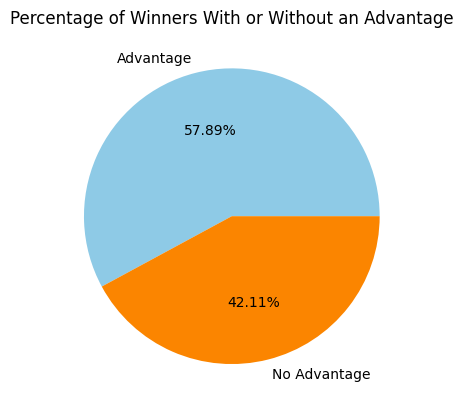

In [257]:
#Visualization of the percentage of winners who had an advantage

plt.title('Percentage of Winners With or Without an Advantage')
plt.pie(df_winner_percentage['count'], labels = df_winner_percentage['advantage_status'], autopct = '%0.2f%%', colors = ['#8ecae6', '#fb8500'])

In [ ]:
#Query: Number of individuals with an advantage grouped by their finale category

Finale_Categorization_Advantage = """
SELECT Castaways.Finale_Categorization,
COUNT(DISTINCT Castaways.Castaway_Id) AS count
FROM Castaways
INNER JOIN Advantage_Movement
    ON Castaways.Season_Castaway_Id = Advantage_Movement.Season_Castaway_Id
    WHERE Castaways.era <> 'Old School (pre-advantage)'
GROUP BY Castaways.Finale_Categorization;
"""

df_finale_categorization_advantage = query(Finale_Categorization_Advantage)
df_finale_categorization_advantage

,Finale_Categorization,count
0,Finalist,32
1,Jury,112
2,Voted Out Pre-Jury,28
3,Winner,21


[Text(0, 0, '32'), Text(0, 0, '112'), Text(0, 0, '28'), Text(0, 0, '21')]

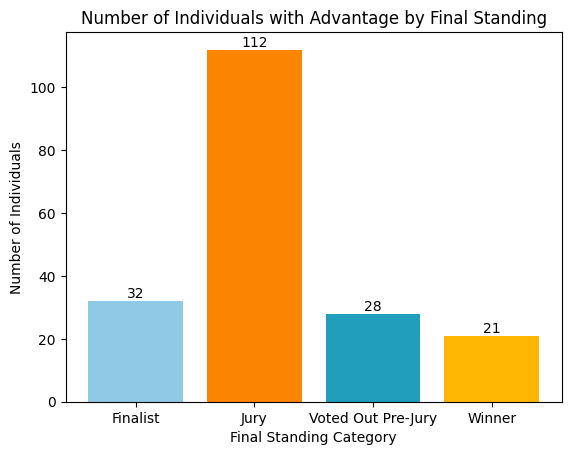

In [267]:
# visualization of number of individuals with an advantage grouped by finale categorization

plt.title('Number of Individuals with Advantage by Final Standing')
bars = plt.bar(df_finale_categorization_advantage['Finale_Categorization'], df_finale_categorization_advantage['count'], color = ['#8ecae6', '#fb8500', '#219ebc', '#ffb703'])
plt.ylabel('Number of Individuals')
plt.xlabel('Final Standing Category')
plt.bar_label(bars)

In [ ]:
#Query: Number of individuals who played an advantage grouped by their finale category

Finale_Categorization_Played_Advantage = """
SELECT Castaways.Finale_Categorization,
COUNT(DISTINCT Castaways.Castaway_Id) AS count
FROM Castaways
INNER JOIN Advantage_Movement
    ON Castaways.Season_Castaway_Id = Advantage_Movement.Season_Castaway_Id
WHERE Castaways.season<49 AND Advantage_Movement.Event = 'Played' AND Castaways.era <> 'Old School (pre-advantage)'
GROUP BY Castaways.Finale_Categorization;
"""

df_finale_categorization_played_advantage = query(Finale_Categorization_Played_Advantage)
df_finale_categorization_played_advantage

,Finale_Categorization,count
0,Finalist,27
1,Jury,61
2,Voted Out Pre-Jury,6
3,Winner,17


[Text(0, 0, '27'), Text(0, 0, '61'), Text(0, 0, '6'), Text(0, 0, '17')]

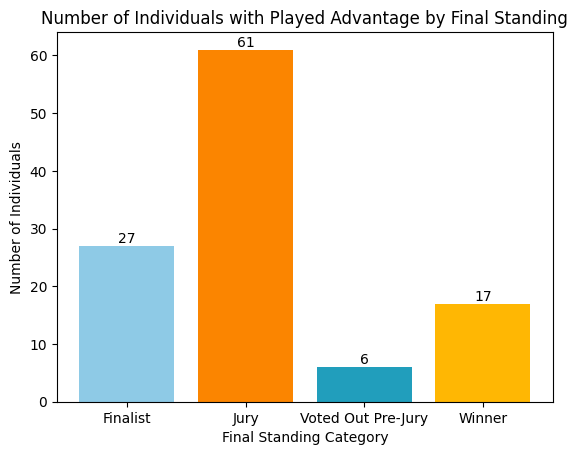

In [268]:
# visualization of number of individuals with an advantage played grouped by finale categorization

plt.title('Number of Individuals with Played Advantage by Final Standing')
bars = plt.bar(df_finale_categorization_played_advantage['Finale_Categorization'], df_finale_categorization_played_advantage['count'], color = ['#8ecae6', '#fb8500', '#219ebc', '#ffb703'])
plt.ylabel('Number of Individuals')
plt.xlabel('Final Standing Category')
plt.bar_label(bars)

In [ ]:
#Query: Number of individuals who successfully played an advantage grouped by their finale category

Finale_Categorization_Successfully_Played_Advantage = """
SELECT Castaways.Finale_Categorization,
COUNT(DISTINCT Castaways.Castaway_Id) AS count
FROM Castaways
INNER JOIN Advantage_Movement
    ON Castaways.Season_Castaway_Id = Advantage_Movement.Season_Castaway_Id
WHERE Castaways.season<49 AND Advantage_Movement.Event = 'Played'AND Advantage_Movement.Success = 'Yes' AND Castaways.era <> 'Old School (pre-advantage)'
GROUP BY Castaways.Finale_Categorization;
"""

df_finale_categorization_successfully_played_advantage = query(Finale_Categorization_Successfully_Played_Advantage)
df_finale_categorization_successfully_played_advantage

,Finale_Categorization,count
0,Finalist,6
1,Jury,28
2,Voted Out Pre-Jury,3
3,Winner,10


[Text(0, 0, '6'), Text(0, 0, '28'), Text(0, 0, '3'), Text(0, 0, '10')]

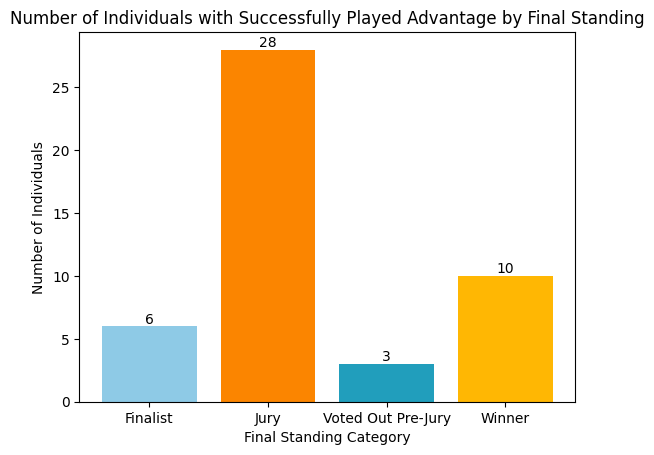

In [292]:
#visualization of number of individuals with an advantage successfully played grouped by finale categorization

plt.title('Number of Individuals with Successfully Played Advantage by Final Standing')
bars = plt.bar(df_finale_categorization_successfully_played_advantage['Finale_Categorization'], df_finale_categorization_successfully_played_advantage['count'], color = ['#8ecae6', '#fb8500', '#219ebc', '#ffb703'])
plt.ylabel('Number of Individuals')
plt.xlabel('Final Standing Category')
plt.bar_label(bars)

In [ ]:

#Query: Number of individuals with an advantage grouped first by era, then by finale category

Era_Finale_Categorization_Advantage = """
SELECT Castaways.Era, Castaways.Finale_Categorization,
COUNT(DISTINCT Castaways.Castaway_Id) AS count
FROM Castaways
INNER JOIN Advantage_Movement
    ON Castaways.Season_Castaway_Id = Advantage_Movement.Season_Castaway_Id
GROUP BY Castaways.Era, Castaways.Finale_Categorization;
"""

df_era_finale_categorization_advantage = query(Era_Finale_Categorization_Advantage)
df_era_finale_categorization_advantage

,Era,Finale_Categorization,count
0,New Era,Finalist,11
1,New Era,Jury,40
2,New Era,Voted Out Pre-Jury,14
3,New Era,Winner,4
4,New School,Finalist,16
5,New School,Jury,60
6,New School,Voted Out Pre-Jury,12
7,New School,Winner,13
8,Old School (with advantages),Finalist,5
9,Old School (with advantages),Jury,13


(array([0, 1, 2]),
 [Text(0, 0, 'Old School (with advantages)'),
  Text(1, 0, 'New School'),
  Text(2, 0, 'New Era')])

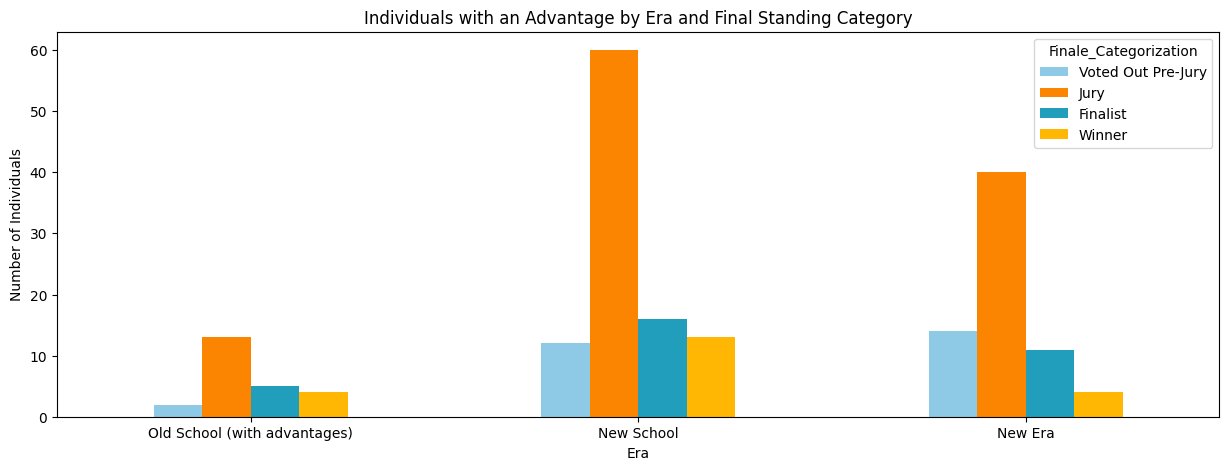

In [320]:
# visualization

era_order = ['Old School (with advantages)', 'New School','New Era' ]
df_era_finale_categorization_advantage['Era'] = pd.Categorical(df_era_finale_categorization_advantage['Era'], categories=era_order, ordered=True)

pivot_df_era_finale_cat_advantage = df_era_finale_categorization_advantage.pivot(index='Era', columns='Finale_Categorization', values='count')
pivot_df_era_finale_cat_advantage = pivot_df_era_finale_cat_advantage.reindex(index=era_order, columns=finale_cat_order)


pivot_df_era_finale_cat_advantage.plot(kind='bar', color = ['#8ecae6', '#fb8500', '#219ebc', '#ffb703'], figsize=(15,5))
plt.title('Individuals with an Advantage by Era and Final Standing Category')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=0)

In [315]:
#Query: Number of individuals who played an advantage grouped first by era, then by finale category

Era_Finale_Categorization_Played_Advantage = """
SELECT Castaways.Era, Castaways.Finale_Categorization,
COUNT(DISTINCT Castaways.Castaway_Id) AS count
FROM Castaways
INNER JOIN Advantage_Movement
    ON Castaways.Season_Castaway_Id = Advantage_Movement.Season_Castaway_Id
WHERE Castaways.season<49 AND Advantage_Movement.Event = 'Played'
GROUP BY Castaways.Era, Castaways.Finale_Categorization;
"""

df_era_finale_cat_played = query(Era_Finale_Categorization_Played_Advantage)
df_era_finale_cat_played

,Era,Finale_Categorization,count
0,New Era,Finalist,10
1,New Era,Jury,19
2,New Era,Voted Out Pre-Jury,3
3,New Era,Winner,3
4,New School,Finalist,13
5,New School,Jury,39
6,New School,Voted Out Pre-Jury,2
7,New School,Winner,12
8,Old School (with advantages),Finalist,4
9,Old School (with advantages),Jury,3


(array([0, 1, 2]),
 [Text(0, 0, 'Old School (with advantages)'),
  Text(1, 0, 'New School'),
  Text(2, 0, 'New Era')])

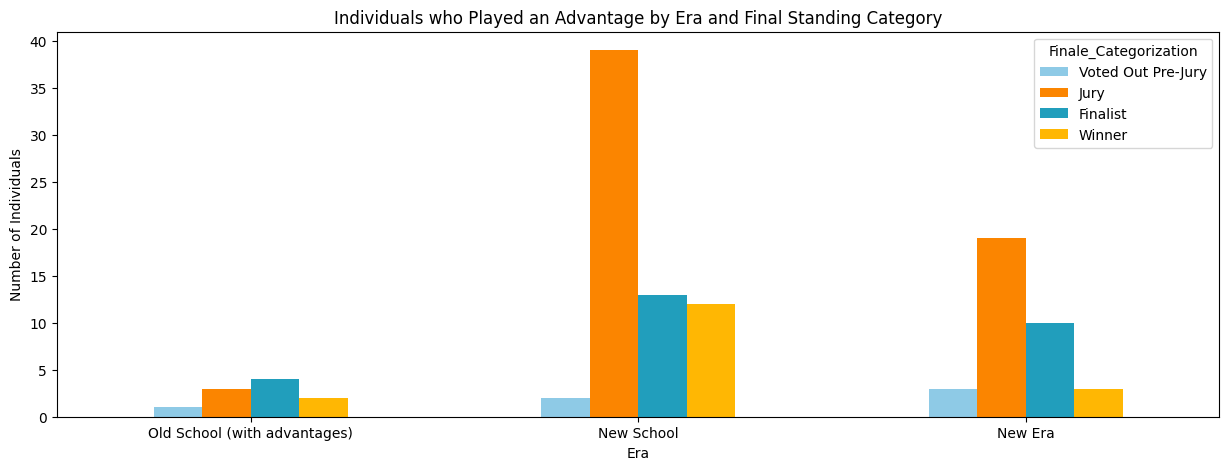

In [319]:
#visualization

era_order = ['Old School (with advantages)', 'New School','New Era' ]
df_era_finale_cat_played['Era'] = pd.Categorical(df_era_finale_cat_played['Era'], categories=era_order, ordered=True)

pivot_df_era_finale_cat_played = df_era_finale_cat_played.pivot(index='Era', columns='Finale_Categorization', values='count')
pivot_df_era_finale_cat_played = pivot_df_era_finale_cat_played.reindex(index=era_order, columns=finale_cat_order)


pivot_df_era_finale_cat_played.plot(kind='bar', color = ['#8ecae6', '#fb8500', '#219ebc', '#ffb703'], figsize=(15,5))
plt.title('Individuals who Played an Advantage by Era and Final Standing Category')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=0)

In [314]:
#Query: Number of individuals who successfully played an advantage grouped first by era, then by finale category

Era_Finale_Categorization_Played_Advantage = """
SELECT Castaways.Era, Castaways.Finale_Categorization,
COUNT(DISTINCT Castaways.Castaway_Id) AS count
FROM Castaways
INNER JOIN Advantage_Movement
    ON Castaways.Season_Castaway_Id = Advantage_Movement.Season_Castaway_Id
WHERE Castaways.season<49 AND Advantage_Movement.Event = 'Played' AND Advantage_Movement.Success = 'Yes'
GROUP BY Castaways.Era, Castaways.Finale_Categorization;
"""

df_era_finale_cat_played_success = query(Era_Finale_Categorization_Played_Advantage)
df_era_finale_cat_played_success

,Era,Finale_Categorization,count
0,New Era,Jury,6
1,New Era,Voted Out Pre-Jury,1
2,New Era,Winner,3
3,New School,Finalist,3
4,New School,Jury,20
5,New School,Voted Out Pre-Jury,1
6,New School,Winner,7
7,Old School (with advantages),Finalist,3
8,Old School (with advantages),Jury,2
9,Old School (with advantages),Voted Out Pre-Jury,1


(array([0, 1, 2]),
 [Text(0, 0, 'Old School (with advantages)'),
  Text(1, 0, 'New School'),
  Text(2, 0, 'New Era')])

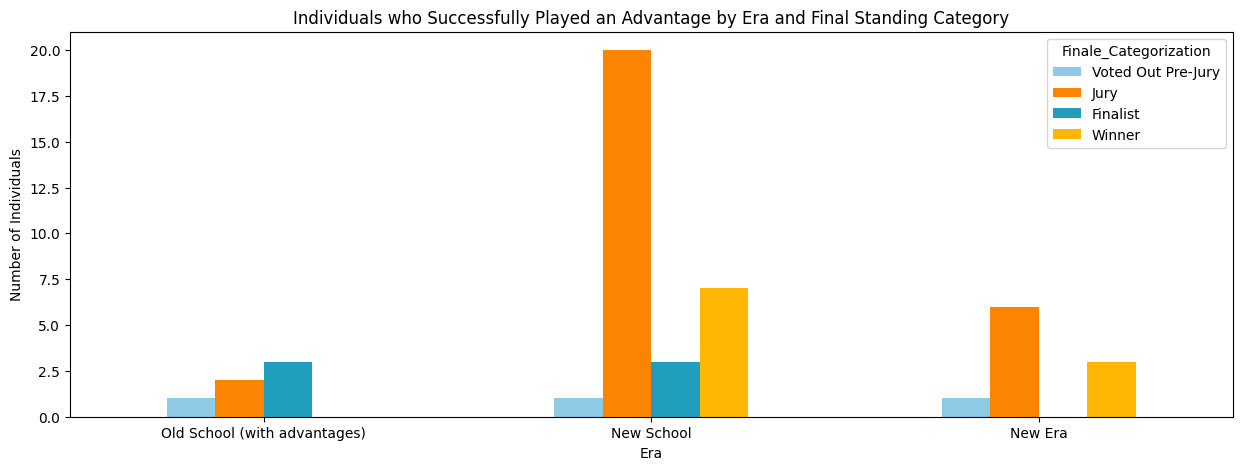

In [318]:
#visualization

era_order = ['Old School (with advantages)', 'New School','New Era' ]
df_era_finale_cat_played_success['Era'] = pd.Categorical(df_era_finale_cat_played_success['Era'], categories=era_order, ordered=True)

pivot_df_era_finale_cat_played_success = df_era_finale_cat_played_success.pivot(index='Era', columns='Finale_Categorization', values='count')
pivot_df_era_finale_cat_played_success = pivot_df_era_finale_cat_played_success.reindex(index=era_order, columns=finale_cat_order)


pivot_df_era_finale_cat_played_success.plot(kind='bar', color = ['#8ecae6', '#fb8500', '#219ebc', '#ffb703'], figsize=(15,5))
plt.title('Individuals who Successfully Played an Advantage by Era and Final Standing Category')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=0)

In [ ]:
#close the connection

conn.close()